
# Triadic Cell Notebook v6
## Broken symmetry addressing

v5 proved something important:

- **BTR** was the only case with real readable activity and memory persistence.
- But **addressing failed**.

Why it failed:
- every memory slot started identical
- the address softmax saw the same score for every slot
- so `slot_focus` stayed flat at **0.25**
- and slot energies stayed equal

That means v5 had **persistence without real selection**.

v6 fixes that by giving memory a proper addressing structure:
1. **slot keys** with broken symmetry
2. **content + key addressing**
3. **competitive write**
4. **top-k selective write gate**
5. **address entropy / focus metrics**

This is the first version where the machine has a shot at deciding
not just **what to keep**,
but **where it belongs**.



## Hardware translation

Use the machine picture:

- **Binding (B)** = protect register + keep identity alive
- **Transformation (T)** = lawful update
- **Readout (R)** = bus projection of meaningful delta
- **Memory keys** = hardwired slot identity / address lines
- **Selective recall** = route to the matching slot
- **Selective write** = only update the addressed lanes

This is closer to real machine behavior:
not one bucket of memory,
but **addressed storage with competition**.


In [1]:

from __future__ import annotations

from dataclasses import dataclass
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
np.set_printoptions(suppress=True, precision=4)

print("Environment ready.")


Environment ready.


In [2]:

@dataclass
class AddressedTriadicState:
    coherence: float = 0.72
    latent: np.ndarray = None
    readout: np.ndarray = None

    def __post_init__(self):
        if self.latent is None:
            self.latent = np.array([0.20, 0.35, 0.50, 0.15], dtype=float)
        if self.readout is None:
            self.readout = np.zeros(2, dtype=float)



## Addressed memory with slot keys

The key change:

- slots are no longer symmetric
- each slot has a fixed key
- addressing compares the current query to those keys
- reads blend slot content by address weight
- writes go mostly to the winning slots

This should break the flat 0.25 problem from v5.


In [3]:

class KeyedMemoryBank:
    def __init__(self, width: int = 4, leak: float = 0.015):
        self.width = width
        self.leak = float(leak)

        # fixed, broken-symmetry slot keys
        self.keys = np.array([
            [1.0, 0.2, 0.0, 0.0],
            [0.0, 1.0, 0.2, 0.0],
            [0.2, 0.0, 1.0, 0.2],
            [0.0, 0.2, 0.0, 1.0],
        ], dtype=float)

        # normalize keys
        self.keys = self.keys / np.linalg.norm(self.keys, axis=1, keepdims=True)

        # slot content
        self.slots = np.zeros((4, width), dtype=float)

    @staticmethod
    def _softmax(x: np.ndarray, temp: float = 1.0) -> np.ndarray:
        z = (x - np.max(x)) / max(temp, 1e-8)
        e = np.exp(z)
        return e / np.sum(e)

    def address(self, query: np.ndarray, content_mix: float = 0.15) -> np.ndarray:
        q = query / (np.linalg.norm(query) + 1e-8)

        key_scores = self.keys @ q

        # optional light content influence
        if np.any(self.slots > 0):
            slot_norms = np.linalg.norm(self.slots, axis=1, keepdims=True) + 1e-8
            slot_dirs = self.slots / slot_norms
            content_scores = slot_dirs @ q
        else:
            content_scores = np.zeros_like(key_scores)

        scores = (1.0 - content_mix) * key_scores + content_mix * content_scores
        return self._softmax(scores, temp=0.08)

    def read(self, weights: np.ndarray) -> np.ndarray:
        return weights @ self.slots

    def write(self, weights: np.ndarray, value: np.ndarray, strength: float, topk: int = 2):
        # decay
        self.slots *= (1.0 - self.leak)

        # selective top-k write
        idx = np.argsort(weights)[::-1][:topk]
        masked = np.zeros_like(weights)
        masked[idx] = weights[idx]
        if masked.sum() > 0:
            masked = masked / masked.sum()

        for i in range(self.slots.shape[0]):
            self.slots[i] = np.clip(
                self.slots[i] + strength * masked[i] * value,
                0.0, 1.0
            )

    def mean_level(self) -> float:
        return float(self.slots.mean())

    def slot_energy(self) -> np.ndarray:
        return self.slots.mean(axis=1)

    def focus(self, weights: np.ndarray) -> float:
        return float(weights.max())

    def entropy(self, weights: np.ndarray) -> float:
        w = np.clip(weights, 1e-12, 1.0)
        return float(-(w * np.log(w)).sum())



## TriadicCellV6

This keeps the v5 machine shape, but fixes the memory path:

1. latent state makes a query
2. keyed bank returns nonuniform address weights
3. recalled content folds into transformation
4. readout still depends on bound transformed difference
5. write gate is triadic and selective


In [4]:

class TriadicCellV6:
    def __init__(self, B: float, T: float, R: float):
        self.B = float(B)
        self.T = float(T)
        self.R = float(R)

        self.W_readout = np.array([
            [1.0, 0.2, 0.0, -0.3],
            [0.0, 0.8, -0.4, 0.6],
        ], dtype=float)

        self.W_query = np.array([
            [1.0, 0.0, 0.3, 0.0],
            [0.0, 1.0, 0.0, 0.4],
            [0.3, 0.0, 1.0, 0.0],
            [0.0, 0.4, 0.0, 1.0],
        ], dtype=float)

    @staticmethod
    def _clip(x):
        return np.clip(x, 0.0, 1.0)

    def step(
        self,
        s: AddressedTriadicState,
        drive_vec: np.ndarray,
        bank: KeyedMemoryBank,
    ) -> Tuple[AddressedTriadicState, np.ndarray, np.ndarray, np.ndarray, np.ndarray, float, float]:

        # --- address / recall ---
        raw_query = self.W_query @ s.latent
        query = raw_query / (np.linalg.norm(raw_query) + 1e-8)
        addr = bank.address(query, content_mix=0.15)
        recalled = bank.read(addr)

        # --- binding / coherence ---
        load = np.linalg.norm(s.readout) + 0.2 * np.linalg.norm(recalled)
        coherence_restore = 0.05 * self.B * (0.84 - s.coherence)
        coherence_burn = 0.07 * self.T * (1.0 - self.B) + 0.008 * load
        coherence = float(np.clip(s.coherence + coherence_restore - coherence_burn, 0.0, 1.0))

        # --- transformation / latent update ---
        target = np.array([
            0.15 + 0.70 * drive_vec[0],
            0.20 + 0.60 * drive_vec[1],
            0.25 + 0.55 * drive_vec[2],
            0.10 + 0.75 * drive_vec[3],
        ], dtype=float)

        composite_target = 0.72 * target + 0.28 * recalled
        follow = 0.20 * self.B * self.T * coherence * (composite_target - s.latent)
        static_drag = 0.04 * (1.0 - self.T) * (s.latent - np.array([0.20, 0.35, 0.50, 0.15]))
        unsupported_loss = 0.14 * self.T * (1.0 - self.B) * s.latent
        latent = self._clip(s.latent + follow - static_drag - unsupported_loss)

        delta_vec = np.abs(latent - s.latent)

        # --- readout / bus ---
        support = self.B * self.T * self.R * coherence
        projected = self.W_readout @ delta_vec
        projected = np.maximum(projected, 0.0)

        shell_decay = (0.18 * (1.0 - self.T) + 0.12 * (1.0 - self.R)) * s.readout
        readout = self._clip(0.82 * s.readout + 2.25 * support * projected - shell_decay)

        # --- triadic write gate ---
        write_strength = float(0.60 * support * readout.mean())
        bank.write(addr, latent, write_strength, topk=2)

        next_state = AddressedTriadicState(
            coherence=coherence,
            latent=latent,
            readout=readout,
        )
        return (
            next_state,
            readout.copy(),
            delta_vec.copy(),
            recalled.copy(),
            addr.copy(),
            write_strength,
            bank.entropy(addr),
        )



## Plain TR addressed baseline

This is still the control:
it can transform, emit, and weakly touch memory,
but without real binding-centered persistence.


In [5]:

class PlainTRAddressedBaselineV6:
    def __init__(self):
        self.W_readout = np.array([
            [1.0, 0.2, 0.0, -0.3],
            [0.0, 0.8, -0.4, 0.6],
        ], dtype=float)

    @staticmethod
    def _clip(x):
        return np.clip(x, 0.0, 1.0)

    def step(
        self,
        s: AddressedTriadicState,
        drive_vec: np.ndarray,
        bank: KeyedMemoryBank,
    ) -> Tuple[AddressedTriadicState, np.ndarray, np.ndarray, np.ndarray, np.ndarray, float, float]:

        query = s.latent / (np.linalg.norm(s.latent) + 1e-8)
        addr = bank.address(query, content_mix=0.15)
        recalled = bank.read(addr)

        coherence = float(np.clip(s.coherence - 0.08 - 0.02 * np.linalg.norm(s.readout), 0.0, 1.0))

        target = np.array([
            0.15 + 0.70 * drive_vec[0],
            0.20 + 0.60 * drive_vec[1],
            0.25 + 0.55 * drive_vec[2],
            0.10 + 0.75 * drive_vec[3],
        ], dtype=float)

        composite_target = 0.72 * target + 0.28 * recalled
        latent = self._clip(s.latent + 0.10 * coherence * (composite_target - s.latent) - 0.18 * s.latent)

        delta_vec = np.abs(latent - s.latent)
        projected = self.W_readout @ delta_vec
        projected = np.maximum(projected, 0.0)
        readout = self._clip(0.65 * s.readout + 1.35 * projected - 0.35 * s.readout)

        write_strength = float(0.08 * readout.mean())
        bank.write(addr, latent, write_strength, topk=2)

        next_state = AddressedTriadicState(
            coherence=coherence,
            latent=latent,
            readout=readout,
        )
        return (
            next_state,
            readout.copy(),
            delta_vec.copy(),
            recalled.copy(),
            addr.copy(),
            write_strength,
            bank.entropy(addr),
        )



## Vector drive


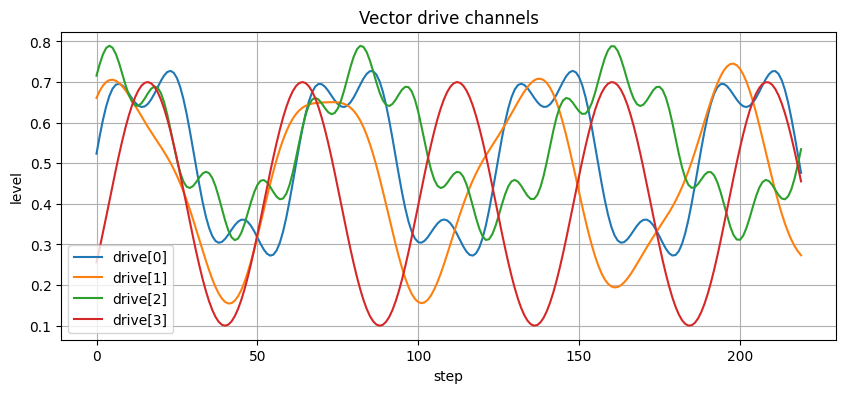

In [6]:

def make_drive(steps: int = 220) -> np.ndarray:
    t = np.linspace(0, 7 * np.pi, steps)

    v0 = np.clip(0.50 + 0.22 * np.sin(t) + 0.08 * np.sin(3.0 * t + 0.3), 0.0, 1.0)
    v1 = np.clip(0.45 + 0.25 * np.sin(t + 0.7) + 0.05 * np.cos(2.2 * t), 0.0, 1.0)
    v2 = np.clip(0.55 + 0.18 * np.cos(0.8 * t - 0.4) + 0.06 * np.sin(4.0 * t), 0.0, 1.0)
    v3 = np.clip(0.40 + 0.30 * np.sin(1.3 * t - 0.5), 0.0, 1.0)

    return np.vstack([v0, v1, v2, v3]).T

drive = make_drive()

plt.figure(figsize=(10, 4))
for i in range(drive.shape[1]):
    plt.plot(drive[:, i], label=f"drive[{i}]")
plt.title("Vector drive channels")
plt.xlabel("step")
plt.ylabel("level")
plt.legend(loc="best")
plt.show()



## Run structural cases + baseline


In [7]:

def run_case(name: str, B: float, T: float, R: float, steps: int = 220) -> Tuple[pd.DataFrame, np.ndarray]:
    cell = TriadicCellV6(B, T, R)
    state = AddressedTriadicState()
    bank = KeyedMemoryBank(width=4, leak=0.015 + 0.08 * (1.0 - B))

    rows: List[Dict[str, float]] = []

    for i, d in enumerate(make_drive(steps)):
        state, readout, delta_vec, recalled, addr, write_strength, entropy = cell.step(state, d, bank)
        rows.append({
            "step": i,
            "case": name,
            "coherence": state.coherence,
            "mean_delta": float(delta_vec.mean()),
            "mean_readout": float(readout.mean()),
            "mean_recall": float(recalled.mean()),
            "mean_memory_bank": bank.mean_level(),
            "write_strength": write_strength,
            "slot_focus": bank.focus(addr),
            "addr_entropy": entropy,
        })

    return pd.DataFrame(rows), bank.slot_energy()


def run_baseline(name: str = "Plain TR addressed baseline", steps: int = 220) -> Tuple[pd.DataFrame, np.ndarray]:
    cell = PlainTRAddressedBaselineV6()
    state = AddressedTriadicState()
    bank = KeyedMemoryBank(width=4, leak=0.015)

    rows: List[Dict[str, float]] = []

    for i, d in enumerate(make_drive(steps)):
        state, readout, delta_vec, recalled, addr, write_strength, entropy = cell.step(state, d, bank)
        rows.append({
            "step": i,
            "case": name,
            "coherence": state.coherence,
            "mean_delta": float(delta_vec.mean()),
            "mean_readout": float(readout.mean()),
            "mean_recall": float(recalled.mean()),
            "mean_memory_bank": bank.mean_level(),
            "write_strength": write_strength,
            "slot_focus": bank.focus(addr),
            "addr_entropy": entropy,
        })

    return pd.DataFrame(rows), bank.slot_energy()

results = {}
slot_energies = {}

for name, vals in {
    "BTR": (1.0, 1.0, 1.0),
    "BT only": (1.0, 1.0, 0.0),
    "BR only": (1.0, 0.0, 1.0),
    "TR only": (0.0, 1.0, 1.0),
}.items():
    df, slots = run_case(name, *vals)
    results[name] = df
    slot_energies[name] = slots

df_base, slots_base = run_baseline()
results["Plain TR addressed baseline"] = df_base
slot_energies["Plain TR addressed baseline"] = slots_base

pd.concat(results.values(), ignore_index=True).head()


,step,case,coherence,mean_delta,mean_readout,mean_recall,mean_memory_bank,write_strength,slot_focus,addr_entropy
0,0,BTR,0.726000,0.012646,0.030238,0.000000,0.001021,0.013172,0.822662,0.614572
1,1,BTR,0.731329,0.012278,0.056078,0.003091,0.002980,0.024607,0.847159,0.477198
2,2,BTR,0.736071,0.011938,0.077865,0.008803,0.005794,0.034388,0.831872,0.512352
3,3,BTR,0.740303,0.012078,0.095111,0.016747,0.009347,0.042247,0.818470,0.543357
4,4,BTR,0.744096,0.012179,0.108005,0.026498,0.013508,0.048220,0.806580,0.571176


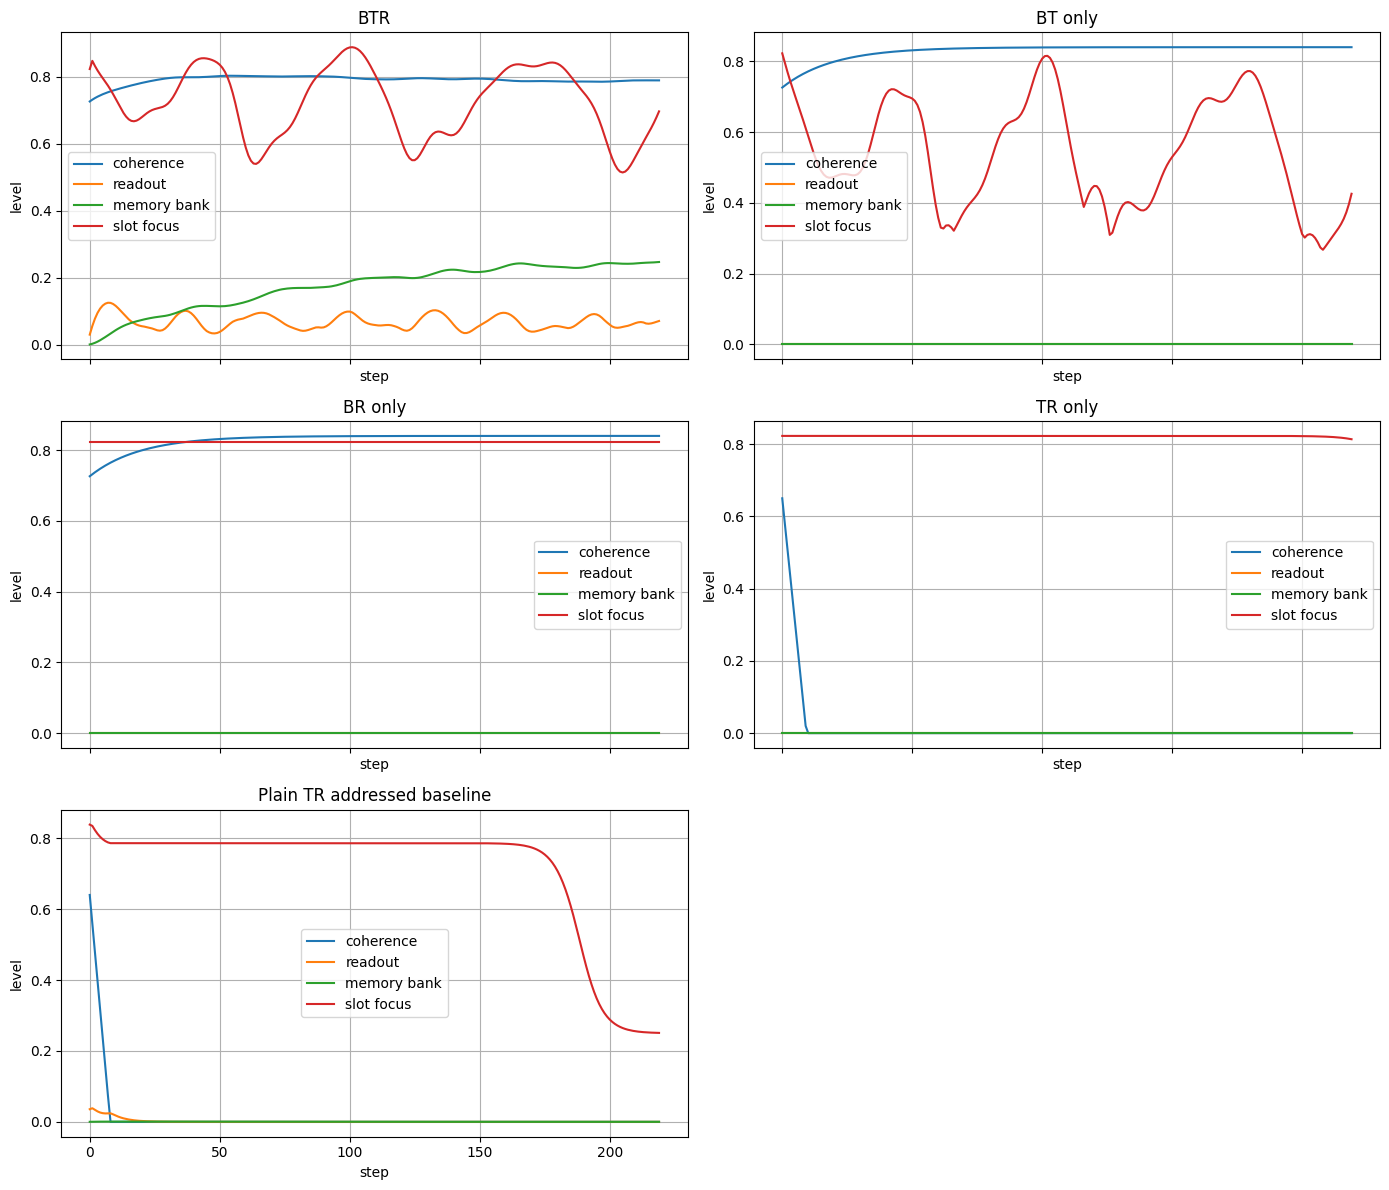

In [8]:

fig, axes = plt.subplots(3, 2, figsize=(14, 12), sharex=True)
axes = axes.ravel()

for ax, (name, df) in zip(axes, results.items()):
    ax.plot(df["step"], df["coherence"], label="coherence")
    ax.plot(df["step"], df["mean_readout"], label="readout")
    ax.plot(df["step"], df["mean_memory_bank"], label="memory bank")
    ax.plot(df["step"], df["slot_focus"], label="slot focus")
    ax.set_title(name)
    ax.set_xlabel("step")
    ax.set_ylabel("level")
    ax.legend(loc="best")

if len(results) < len(axes):
    for ax in axes[len(results):]:
        ax.axis("off")

plt.tight_layout()
plt.show()



## Summary table


In [9]:

summary = pd.DataFrame([
    {
        "case": name,
        "final_coherence": df["coherence"].iloc[-1],
        "final_readout": df["mean_readout"].iloc[-1],
        "final_memory_bank": df["mean_memory_bank"].iloc[-1],
        "final_slot_focus": df["slot_focus"].iloc[-1],
        "mean_coherence": df["coherence"].mean(),
        "mean_delta": df["mean_delta"].mean(),
        "mean_readout": df["mean_readout"].mean(),
        "mean_recall": df["mean_recall"].mean(),
        "mean_memory_bank": df["mean_memory_bank"].mean(),
        "mean_write_strength": df["write_strength"].mean(),
        "mean_slot_focus": df["slot_focus"].mean(),
        "mean_addr_entropy": df["addr_entropy"].mean(),
    }
    for name, df in results.items()
]).sort_values(["mean_memory_bank", "mean_readout"], ascending=False)

summary


,case,final_coherence,final_readout,final_memory_bank,final_slot_focus,mean_coherence,mean_delta,mean_readout,mean_recall,mean_memory_bank,mean_write_strength,mean_slot_focus,mean_addr_entropy
0,BTR,0.788857,7.098341e-02,0.246965,0.696385,0.790270,0.006617,0.068001,0.419421,0.174283,0.032207,0.724065,0.744045
4,Plain TR addressed baseline,0.000000,1.746535e-20,0.000034,0.250921,0.012972,0.001364,0.001731,0.000703,0.000261,0.000139,0.710564,0.684519
1,BT only,0.839998,0.000000e+00,0.000000,0.425781,0.829636,0.006935,0.000000,0.000000,0.000000,0.000000,0.541076,1.096229
2,BR only,0.839998,0.000000e+00,0.000000,0.822662,0.829636,0.000000,0.000000,0.000000,0.000000,0.000000,0.822662,0.614572
3,TR only,0.000000,0.000000e+00,0.000000,0.813500,0.015227,0.001364,0.000000,0.000000,0.000000,0.000000,0.822364,0.615342



## Slot energy by case

This should no longer be perfectly flat if selective addressing is working.


In [10]:

slot_df = pd.DataFrame(slot_energies).T
slot_df.columns = [f"slot_{i}" for i in range(slot_df.shape[1])]
slot_df


,slot_0,slot_1,slot_2,slot_3
BTR,0.0,0.247085,0.740774,0.0
BT only,0.0,0.000000,0.000000,0.0
BR only,0.0,0.000000,0.000000,0.0
TR only,0.0,0.000000,0.000000,0.0
Plain TR addressed baseline,0.0,0.000025,0.000113,0.0



## Scorecard


In [11]:

def classify(df: pd.DataFrame) -> Dict[str, str]:
    mean_c = df["coherence"].mean()
    mean_d = df["mean_delta"].mean()
    mean_r = df["mean_readout"].mean()
    mean_m = df["mean_memory_bank"].mean()
    mean_f = df["slot_focus"].mean()

    return {
        "coherence": "high" if mean_c > 0.58 else "low",
        "statefulness": "high" if mean_d > 0.006 else "low",
        "readability": "high" if mean_r > 0.05 else "low",
        "memory": "high" if mean_m > 0.08 else "low",
        "address_focus": "high" if mean_f > 0.35 else "low",
    }

scorecard = pd.DataFrame({name: classify(df) for name, df in results.items()}).T
scorecard


,coherence,statefulness,readability,memory,address_focus
BTR,high,high,high,high,high
BT only,high,high,low,low,high
BR only,high,low,low,low,high
TR only,low,low,low,low,high
Plain TR addressed baseline,low,low,low,low,high



## One chained addressed BTR machine


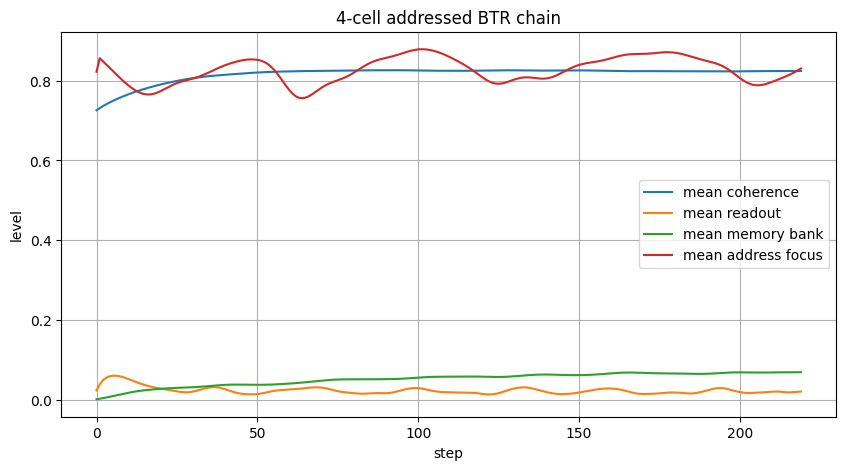

,step,mean_coherence,mean_readout,mean_memory_bank,mean_delta,mean_focus,mean_entropy
215,215,0.824524,0.017942,0.068294,0.001132,0.813625,0.558172
216,216,0.824549,0.018102,0.068317,0.001479,0.817416,0.553396
217,217,0.824568,0.018618,0.068364,0.001836,0.821544,0.547371
218,218,0.824577,0.019308,0.068444,0.002180,0.826081,0.539947
219,219,0.824574,0.020005,0.068554,0.002484,0.831046,0.531051


In [12]:

def run_chain(depth: int = 4, steps: int = 220, B: float = 1.0, T: float = 1.0, R: float = 1.0) -> pd.DataFrame:
    cells = [TriadicCellV6(B, T, R) for _ in range(depth)]
    states = [AddressedTriadicState() for _ in range(depth)]
    banks = [KeyedMemoryBank(width=4, leak=0.015) for _ in range(depth)]

    rows = []

    for i, d in enumerate(make_drive(steps)):
        signal = d.copy()
        deltas = []
        foci = []
        entropies = []

        for j, cell in enumerate(cells):
            states[j], readout, delta_vec, recalled, addr, write_strength, entropy = cell.step(states[j], signal, banks[j])

            signal = np.array([
                readout[0],
                readout[1],
                recalled.mean(),
                banks[j].mean_level(),
            ], dtype=float)

            deltas.append(delta_vec.mean())
            foci.append(addr.max())
            entropies.append(entropy)

        rows.append({
            "step": i,
            "mean_coherence": np.mean([s.coherence for s in states]),
            "mean_readout": np.mean([s.readout.mean() for s in states]),
            "mean_memory_bank": np.mean([b.mean_level() for b in banks]),
            "mean_delta": np.mean(deltas),
            "mean_focus": np.mean(foci),
            "mean_entropy": np.mean(entropies),
        })

    return pd.DataFrame(rows)

chain_df = run_chain(depth=4, steps=220, B=1.0, T=1.0, R=1.0)

plt.figure(figsize=(10, 5))
plt.plot(chain_df["step"], chain_df["mean_coherence"], label="mean coherence")
plt.plot(chain_df["step"], chain_df["mean_readout"], label="mean readout")
plt.plot(chain_df["step"], chain_df["mean_memory_bank"], label="mean memory bank")
plt.plot(chain_df["step"], chain_df["mean_focus"], label="mean address focus")
plt.title("4-cell addressed BTR chain")
plt.xlabel("step")
plt.ylabel("level")
plt.legend(loc="best")
plt.show()

chain_df.tail()



## Read the result

The intended pattern now is:

- **BTR** should be the only case that is strong on:
  - coherence
  - readable activity
  - memory persistence
  - nontrivial address focus
- **BT only** should stay alive internally but not write meaningful readable memory
- **BR only** should remain a coherent shell
- **TR only** should collapse
- **Plain TR addressed baseline** should look weaker and noisier than real BTR

And unlike v5:
- slot energies should not all be identical
- address focus should not stay flat at 0.25
